In [1]:
import torch
import torch.nn.functional as F
import torch.nn as nn
from torch import Tensor

# __1. Cài đặt attention mechanism từ đầu (scaled dot-product)__

## 1.1. Công thức scaled dot-product attention
$$
\text{Attention}(Q, K, V) = \text{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$
Với:
+ $\sqrt{d_k}$: là căn bậc 2 của số chiều của mỗi key

input (Tensor) – tensor đầu vào

dim0 (int) – chiều thứ nhất cần hoán đổi

dim1 (int) – chiều thứ hai cần hoán đổi

In [2]:
def scaled_dot_product_attention(Q, K, V, mask=None):
  # Q, K, V có shape (..., seq_len, d_k)
  d_k = Q.size(-1)
  score = Q @ K.transpose(-2, -1) # dim0, dim1
  score = score / (d_k**0.5)
  if mask is not None:
    score = score.masked_fill(mask == 0, float('-inf'))
  attn_weights = F.softmax(score)
  output = attn_weights @ V
  return output, attn_weights

In [3]:
torch.manual_seed(0)
seq_len, d_k = 4, 8
Q = torch.randn(seq_len, d_k)
K = torch.randn(seq_len, d_k)
V = torch.randn(seq_len, d_k)

out, w = scaled_dot_product_attention(Q, K, V)
print("Output shape:", out.shape)          # torch.Size([4, 8])
print("Trọng số chú ý (mỗi hàng cộng = 1):")
print(w)
print("Tổng mỗi hàng:", w.sum(dim=-1))     # ~ tensor([1., 1., 1., 1.])

Output shape: torch.Size([4, 8])
Trọng số chú ý (mỗi hàng cộng = 1):
tensor([[0.1211, 0.7410, 0.1060, 0.0320],
        [0.2577, 0.2651, 0.1705, 0.3067],
        [0.3360, 0.0171, 0.1869, 0.4599],
        [0.2032, 0.6235, 0.1025, 0.0708]])
Tổng mỗi hàng: tensor([1.0000, 1.0000, 1.0000, 1.0000])


/tmp/ipykernel_3089/2518307042.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  attn_weights = F.softmax(score)


Do $QK^T$ là tổng của nhiều hạng số nhân với nhau nên giá trị có xu hướng phình to. Và khi gặp softmax, nó dồn gần như 100% chú ý vào cùng 1 từ và bóp các từ khác về 0

# __2. Xây dựng multi-head attention__

## 2.1. Một đầu attention làm gì
Mỗi 1 `head` nhận vào $Q,K,V$ rồi tính scaled dot
$$
\text{Attention}(Q,K,V)=\text{softmax}(\frac{QK^T}{\sqrt{d_k}})V
$$
+ Mỗi 1 head là 1 góc nhìn về từ nào nên chú ý tới từ nào
+ Vấn đề là nếu chỉ có 1 head thì mô hình bị ép mọi loại quan hệ vào 1 tập trọng số duy nhất. Giống như bắt một người vừa làm phiên dịch, vừa làm kế toán, vừa làm bảo vệ cùng lúc - làm được nhưng chả cái nào giỏi.

## 2.2. Ý tưởng của multi-head
+ Ý tưởng của multi-head là chia để trị
+ Thay vì để 1 attention tập trung trên toàn bộ $d_{model}$ chiều, ta sẽ `chia không gian thành h phần nhỏ`

|Ký hiệu|Ý nghĩa|Ví dụ|
|-|-|-|
|$d_{model}$|Số chiều `embedding` của mỗi model|512|
|$h$|Số head (số attention song song)|8|
|$d_k=\frac{d_{model}}{h}$|Số chiều mỗi head xử lý|512/8=64|
|$d_v$|Chiều value mỗi head|64|

Công thức tổng quát
$$
\text{head}_i=\text{Attention}(QW^Q_i, KW^K_i, VW^V_i)
$$

$$
\text{multihead}(Q,K,V)=\text{Concat}(head_1, ..., head_h)W^O
$$

+ Ghép: nối kết quả $h$ lại thành vector dài $h\times d_v=d_{model}$
+ $W^O$: ma trận trọng số đầu ra

In [4]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model=512, num_heads=8):
    super().__init__()
    assert d_model % num_heads == 0, "d_model phải chia hết cho num_heads"

    self.d_model = d_model
    self.num_heads = num_heads
    self.d_k = d_model // num_heads

    # 3 phép chiếu Q, K, V gộp chung, + 1 phép trộn cuối W^O
    # Về lý thuyết, mỗi head có W_i^Q riêng với shape (d_model, d_k) trong đó d_k = d_model / h. Nhưng thay vì tạo h ma trận nhỏ, người ta ghép chúng lại thành 1 ma trận lớn:
    self.W_Q = nn.Linear(d_model, d_model)
    self.W_K = nn.Linear(d_model, d_model)
    self.W_V = nn.Linear(d_model, d_model)
    self.W_O = nn.Linear(d_model, d_model)

  def split_head(self, x: Tensor):
    # x: [batch, seq, d_model] -> [batch, h, seq, d_k]
    batch, seq, _ = x.shape
    # không viết return x.view(batch, self.num_heads, seq, self.d_k) vì x có shape
    # (b, seq, d_model), và trong bộ nhớ, d_model là chiều liên tục cuối cùng (contiguous). Khi tách d_model thành (h, d_k), phải tách đúng vị trí của nó — tức là ngay sau seq
    return x.view(batch, seq, self.num_heads, self.d_k).transpose(1, 2)

  def __scaled_dot_product(self, Q: Tensor, K:Tensor, V: Tensor, mask=None):
    scores = Q @ K.transpose(-2, -1) / (self.d_k ** 0.5)
    if mask is not None:
      scores = scores.masked_fill(mask == 0, float('-inf'))
    attn_weights = F.softmax(scores, dim=-1)
    return attn_weights @ V

  def forward(self, q: Tensor, k:Tensor, v:Tensor, mask=None):
    batch, seq, _ = q.shape
    Q = self.split_head(self.W_Q(q)) # [b, h, seq, d_k]
    K = self.split_head(self.W_K(k)) # [b, h, seq, d_k]
    V = self.split_head(self.W_V(v)) # [b, h, seq, d_k]
    attn = self.__scaled_dot_product(Q, K, V, mask)
    # transpose(1, 2) để đưa về [batch, seq, h, d_k]
    out = attn.transpose(1, 2)
    # concat và gộp d_model = h * d_k
    out = out.contiguous().view(batch, seq, self.d_model)
    return self.W_O(out)

## 2.3. Dùng `nn.MultiheadAttention` có sẵn của PyTorch

Các tham số

|Tham số|Ý nghĩa|Lưu ý|
|-|-|-|
|`embed_dim`|$d_{model}$|phải chia hết cho `num_heads`|
|`batch_first`|thứ tự chiều|True -> [batch, seq, dim] (dễ đọc hơn)|

In [5]:
pytorch_mha = nn.MultiheadAttention(embed_dim=512, num_heads=8)

## __3. Encoder và decoder__

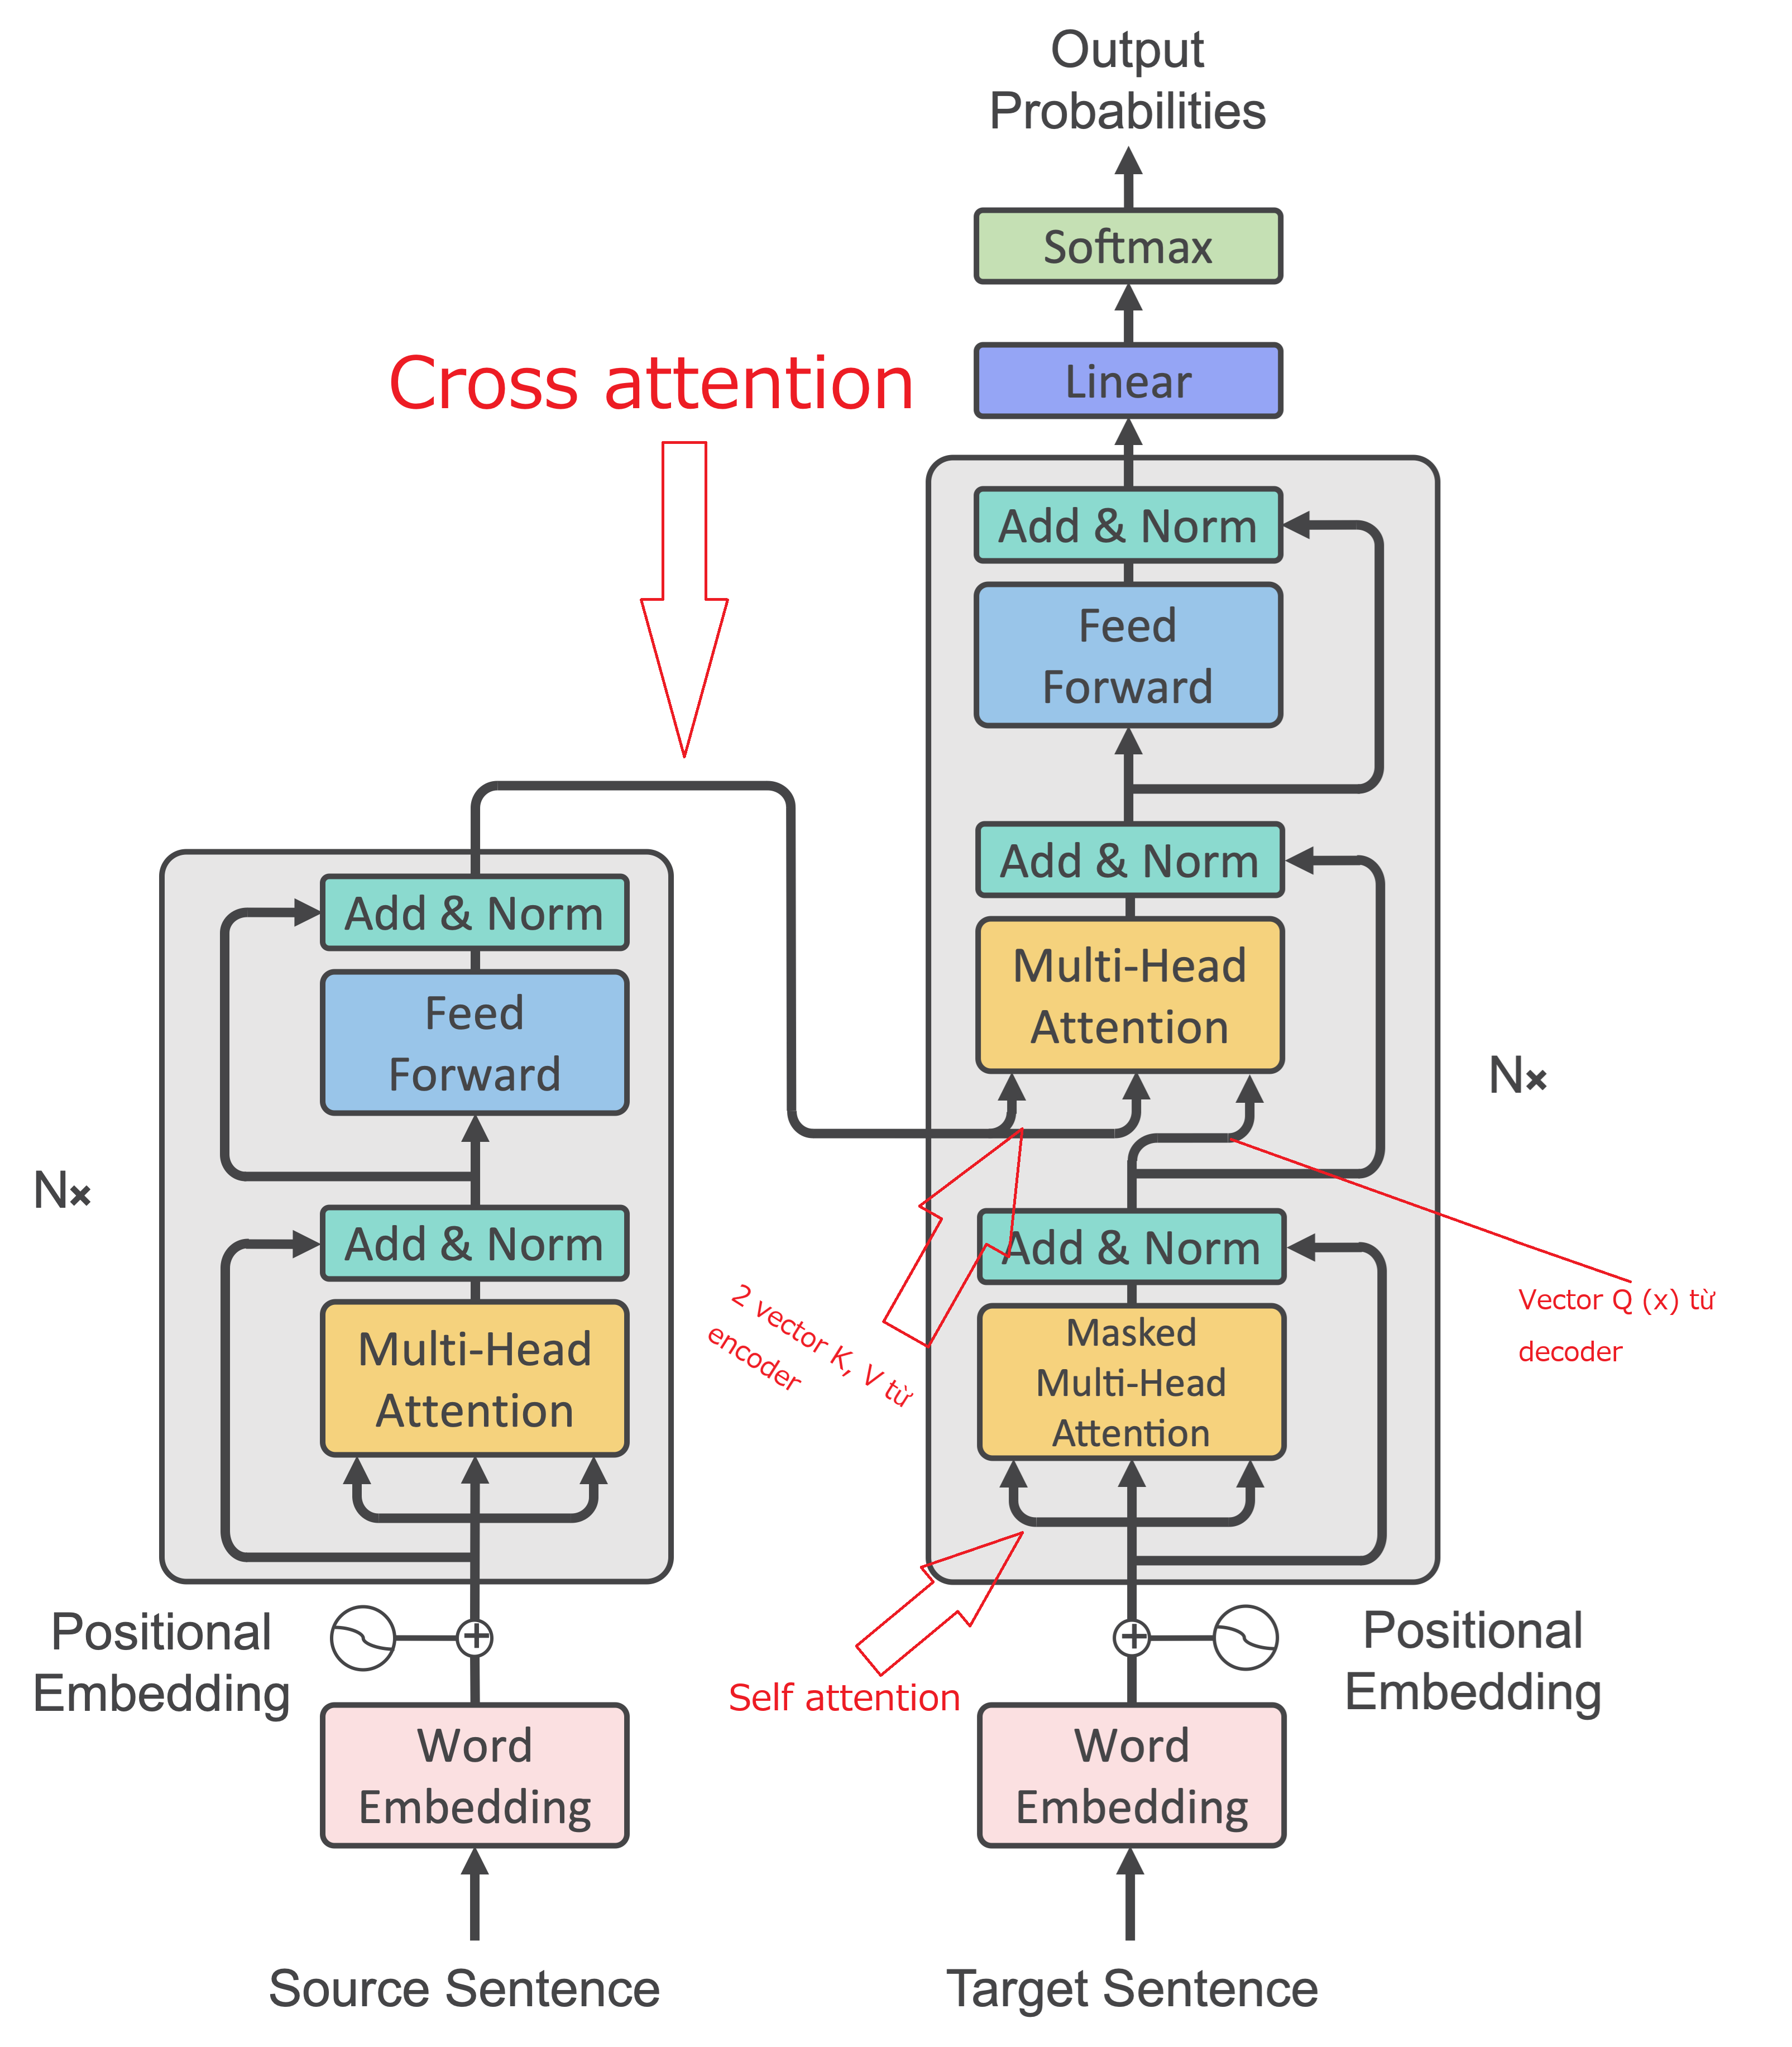

In [6]:
class EncoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, dim_ff=1024, dropout=0.1):
    # dim_ff: dim feed forward (fully connected layer)
    super().__init__()
    self.attn = MultiHeadAttention(d_model, num_heads)
    self.dropout = nn.Dropout(dropout)
    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.feed_forward = nn.Sequential(
        nn.Linear(d_model, dim_ff),
        nn.ReLU(),
        nn.Linear(dim_ff, dim_ff),
        nn.ReLU(),
        nn.Linear(dim_ff, d_model)
    )

  def forward(self, x: Tensor, src_mask=None):
    attn_out = self.attn(x, x, x, mask=src_mask)
    x = self.norm1(x + self.dropout(attn_out))

    ff_out = self.feed_forward(x)
    x = self.norm2(x + self.dropout(ff_out))
    return x

In [7]:
class Encoder(nn.Module):
  def __init__(self, d_model, num_heads, dim_ff=1024, dropout=0.1, num_layers=1):
    super().__init__()
    self.layers = nn.ModuleList([
        EncoderLayer(d_model, num_heads, dim_ff, dropout)
        for _ in range(num_layers)
    ])
    self.norm = nn.LayerNorm(d_model)

  def forward(self, x: Tensor, src_mask=None):
    for layer in self.layers:
      x = layer(x, src_mask)
    return self.norm(x)

In [8]:
class DecoderLayer(nn.Module):
  def __init__(self, d_model, num_heads, dim_ff=1024, dropout=0.1):
    super().__init__()
    self.self_attn = MultiHeadAttention(d_model, num_heads)
    self.cross_attn = MultiHeadAttention(d_model, num_heads)

    self.feed_forward = nn.Sequential(
        nn.Linear(d_model, dim_ff),
        nn.ReLU(),
        nn.Linear(dim_ff, dim_ff),
        nn.ReLU(),
        nn.Linear(dim_ff, d_model)
    )

    self.norm1 = nn.LayerNorm(d_model)
    self.norm2 = nn.LayerNorm(d_model)
    self.norm3 = nn.LayerNorm(d_model)
    self.dropout = nn.Dropout(dropout)

  def forward(self, x: Tensor, memory: Tensor, target_mask=None, memory_mask=None):
    # 1. Masked self-attention (không cho nhìn tương lai)
    # x là đầu vào, memory là từ encoder
    attn_out = self.self_attn(x, x, x, target_mask) # (Q, K, V, mask)
    x = self.norm1(x + self.dropout(attn_out))

    # 2. Cross-attention: Query từ decoder (x), Key/Value từ encoder output (memory)
    cross_out = self.cross_attn(x, memory, memory, memory_mask)
    x = self.norm2(x + self.dropout(cross_out))

    # Feed forward
    ff = self.feed_forward(x)
    x = self.norm3(x + self.dropout(ff))
    return x

In [9]:
class Decoder(nn.Module):
  def __init__(self, d_model, num_heads, num_layers, dim_ff=1024, dropout=0.1):
    super().__init__()
    self.layers = nn.ModuleList([
        DecoderLayer(d_model, num_heads, dim_ff, dropout)
        for _ in range(num_layers)
    ])

  def forward(self, x: Tensor, memory: Tensor, target_mask=None, memory_mask=None):
    for layer in self.layers:
      x = layer(x, memory, target_mask, memory_mask)
    return x

In [10]:
class Transformer(nn.Module):
  def __init__(self, encoder, decoder, d_model, vocab_size_target):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder
    self.d_model = d_model
    self.generator = nn.Linear(d_model, vocab_size_target)

  def forward(self, src_emb, target_emb, src_mask=None, target_mask=None, memory_mask=None):
    memory = self.encoder(src_emb, src_mask)
    output = self.decoder(target_emb, memory, target_mask, memory_mask)
    output = self.generator(output)
    return output

In [11]:
d_model = 1028
num_heads = 4
num_layers = 4
vocab_size_target = 200000
vocab_size_src = 200000

In [12]:
encoder = Encoder(d_model, num_heads, num_layers=num_layers)
decoder = Decoder(d_model, num_heads, num_layers=num_layers)
transformer = Transformer(encoder, decoder, d_model, vocab_size_target)

Decoder cần causal mask (để không "nhìn thấy" token tương lai) và padding mask (để bỏ qua token padding):

In [13]:
# chưa hiểu cái này lắm
def generate_padding_mask(seq, pad_idx):
    # seq: [batch, seq_len]
    # trả về: [batch, 1, 1, seq_len], giá trị 1 = giữ, 0 = che (để khớp code masked_fill(mask==0,...))
    mask = (seq != pad_idx).unsqueeze(1).unsqueeze(2)  # [batch, 1, 1, seq_len]
    return mask

def generate_causal_mask(size, device):
    # trả về [1, 1, size, size], giá trị 1 = giữ, 0 = che
    mask = torch.tril(torch.ones(size, size, device=device)).bool()
    return mask.unsqueeze(0).unsqueeze(0)

In [14]:
# Đọc lại
class PositionalEmbedding(nn.Module):
  def __init__(self, vocab_size, d_model, max_len=1024):
    super().__init__()
    self.token_emb = nn.Embedding(vocab_size, d_model)
    self.pos_emb = nn.Embedding(max_len, d_model)

  def forward(self, x):
    pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
    return self.token_emb(x) + self.pos_emb(pos)

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
transformer = transformer.to(device)

cuda


In [17]:
src_embedder = PositionalEmbedding(vocab_size_src, d_model).to(device)
tgt_embedder = PositionalEmbedding(vocab_size_target, d_model).to(device)

In [18]:
criterion = nn.CrossEntropyLoss(ignore_index=0)  # 0 = pad token
optimizer = optim.Adam(
    list(transformer.parameters()) +
    list(src_embedder.parameters()) +
    list(tgt_embedder.parameters()),
    lr=1e-4, betas=(0.9, 0.98), eps=1e-9
)

In [19]:
# Chưa hiểu cái này lắm
def train_epoch(dataloader: DataLoader, pad_idx_src, pad_idx_tgt, num_epochs=10):
  transformer.train()
  total_loss = 0
  for epoch in range(num_epochs):
    for batch in dataloader:
      src, tgt = batch['src'].to(device), batch['tgt'].to(device)
      tgt_input = tgt[:, :-1]
      tgt_label = tgt[:, 1:]

      src_emb = src_embedder(src)
      tgt_emb = tgt_embedder(tgt_input)

      src_mask = generate_padding_mask(src, pad_idx_src).to(device)          # [batch,1,1,src_len]
      tgt_pad_mask = generate_padding_mask(tgt_input, pad_idx_tgt).to(device) # [batch,1,1,tgt_len]
      tgt_causal = generate_causal_mask(tgt_input.size(1), device)            # [1,1,tgt_len,tgt_len]
      tgt_mask = tgt_pad_mask & tgt_causal   # kết hợp cả 2, shape [batch,1,tgt_len,tgt_len]

      memory_mask = src_mask  # dùng cho cross-attention decoder->encoder, [batch,1,1,src_len]

      optimizer.zero_grad()
      output = transformer(src_emb, tgt_emb, src_mask, tgt_mask, memory_mask)
      loss = criterion(output.reshape(-1, output.size(-1)), tgt_label.reshape(-1)) # Dùng reshape thay vì view
      loss.backward()
      optimizer.step()
    if (epoch + 1) % 10 == 0:
      print(f"epoch {epoch+1}: {loss.item():.4f}")

# Chuẩn bị data

In [20]:
from torch.utils.data import random_split

In [21]:
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers import Tokenizer, pre_tokenizers

In [22]:
train_vi_path = "/content/drive/MyDrive/dataset/train/train.vi"
train_zh_path = "/content/drive/MyDrive/dataset/train/train.zh"

In [23]:
def get_tokenizer(path, lang):
  # 1. Khởi tạo
  tokenizer = Tokenizer(BPE(unk_token='[UNK]'))
  # 2. Thêm bước tiền xử lý (pre-tokenizer)
  if lang == "vi":
    tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()
  elif len == "zh":
    tokenizer.pre_tokenizer = pre_tokenizers.BertPreTokenizer() # BertPre: tách từng ký tự -> phù hợp cho JP, CN, KR
  # 3. Khởi tạo trainer
  trainer = BpeTrainer(special_tokens=["[UNK]", "[PAD]", "[SOS]", "[EOS]"]) # !!!!!!!!!!!!!!!!
  # 4. Train tokenizer
  tokenizer.train([path], trainer)
  return tokenizer

In [24]:
tokenizer_vi = get_tokenizer(train_vi_path, "vi")
tokenizer_zh = get_tokenizer(train_zh_path, "zh")

In [25]:
print(tokenizer_zh.decode(tokenizer_zh.encode("你好").ids))
print(tokenizer_vi.decode(tokenizer_vi.encode("xinchào").ids))

你 好
xin chào


In [26]:
class CustomDataset(Dataset):
  def __init__(self, vi_path, zh_path, tokenizer_vi, tokenizer_zh, max_len=1024):
    with open(vi_path, "r") as f:
      self.vi_lines = f.readlines()
    with open(zh_path, "r") as f:
      self.zh_lines = f.readlines()
    assert len(self.vi_lines) == len(self.zh_lines)
    self.tokenizer_vi = tokenizer_vi
    self.tokenizer_zh = tokenizer_zh
    self.max_len = max_len

  def __len__(self):
    return len(self.vi_lines)

  def __getitem__(self, idx):
    # lấy index
    vi = self.vi_lines[idx].strip().lower()
    zh = self.zh_lines[idx].strip().lower()

    # Chuyển sang token ids
    vi_ids = self.tokenizer_vi.encode(vi).ids
    zh_ids = self.tokenizer_zh.encode(zh).ids

    # Lấy SOS, EOS
    vi_eos = self.tokenizer_vi.token_to_id('[EOS]')
    vi_sos = self.tokenizer_vi.token_to_id('[SOS]')
    zh_eos = self.tokenizer_zh.token_to_id('[EOS]')
    zh_sos = self.tokenizer_zh.token_to_id('[SOS]')

    # Trả về [SOS] + data + [EOS]
    return {
        "src": torch.tensor([vi_sos] + vi_ids[:self.max_len-2] + [vi_eos], dtype=torch.long),
        "tgt": torch.tensor([zh_sos] + zh_ids[:self.max_len-2] + [zh_eos], dtype=torch.long),
    }

In [27]:
from torch.nn.utils.rnn import pad_sequence
def collate_fn(batch):
  pad_id_vi = tokenizer_vi.token_to_id('[PAD]')
  pad_id_zh = tokenizer_zh.token_to_id('[PAD]')
  src_batch = [item['src'] for item in batch]
  tgt_batch = [item['tgt'] for item in batch]

  src_batch = pad_sequence(src_batch, batch_first=True, padding_value=pad_id_vi)
  tgt_batch = pad_sequence(tgt_batch, batch_first=True, padding_value=pad_id_zh)
  return {
        "src": src_batch,
        "tgt": tgt_batch
  }

In [28]:
dataset = CustomDataset(train_vi_path, train_zh_path, tokenizer_vi, tokenizer_zh)

In [29]:
train_size = int(len(dataset) * 0.9)
val_size = len(dataset) - train_size

In [30]:
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

In [31]:
from functools import partial
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=partial(collate_fn))
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=partial(collate_fn))

In [ ]:
train_epoch(train_loader,tokenizer_vi.token_to_id("[PAD]"), tokenizer_zh.token_to_id("[PAD]"))